In [1]:
from jax_signatures.signature import * 
from jax_signatures.exact_representations import * 
from schemes import * 
from trajectories import *
from utils import *

from matplotlib.ticker import FuncFormatter
import time 

## I. Signature representation of an Ornstein-Uhlenbeck process

### I.1. Two-sided Brownian motion

In [23]:
T = 4
T0 = -4
n1 = 500 # coarser grid for the burn-in 
n2 = T * 365 * 5 + 1
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0)

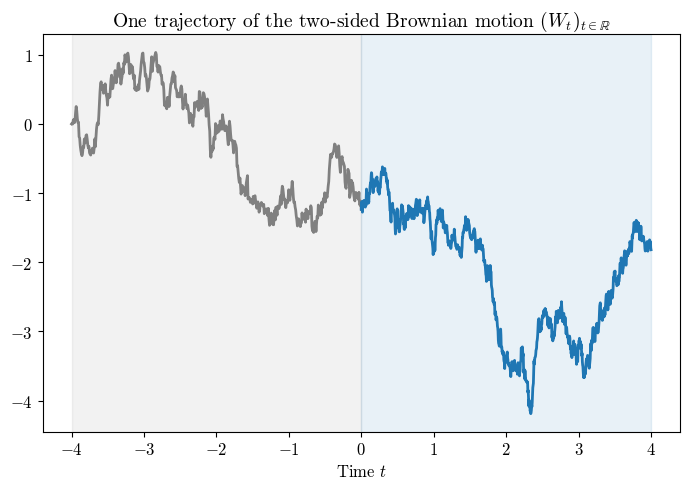

In [24]:
fig, ax = plt.subplots(figsize=(7,5))

ax.axvspan(xmin=t_burn[0], xmax=0, color="gray", alpha=0.10)
ax.axvspan(xmin=0, xmax=t_main[-1], color="tab:blue", alpha=0.10)

idx=0
ax.plot(t_burn, paths[idx, :len(t_burn), 1], lw=2, color="gray")
ax.plot(t_main, paths[idx, len(t_burn):, 1], lw=2, color="tab:blue")

ax.xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax.yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax.tick_params(labelsize=12, axis="both")
ax.set_title(r"$\text{One trajectory of the two-sided Brownian motion }(W_t)_{t\in \mathbb{R}}$", fontsize=14)
ax.set_xlabel(r"$\text{Time }t$", fontsize=12)
plt.tight_layout()
plt.show()

### I.2. Comparison with the classical signature $(\boldsymbol{\lambda} = 0)$

In [25]:
lambd = jnp.array([5.0, 5.0])
mu, theta, eta = 5, 1.0, 1.5

X_true = simulate_Langevin_Euler(0.0, mu, theta, eta, paths)
x = X_true[0, len(t_burn)]
x

np.float64(0.5045644577036779)

In [26]:
M_values = np.arange(1, 11)

traj_EFM_sig = []
traj_sig = [] 

for M in tqdm(M_values) : 
    l = compute_l_EFM_OU(lambd, mu, theta, eta, M)
    EFM_sig = compute_EFM_signature(paths, t_grid, lambd, M) 
    traj_EFM_sig.append((EFM_sig @ l).T)
    traj_sig.append(simulate_OU_signatures(M, x, mu, theta, eta, paths[:, len(t_burn):, :]))

traj_EFM_sig = np.array(traj_EFM_sig)
traj_sig = np.array(traj_sig)

100%|███████████████████████████████████████████| 10/10 [01:04<00:00,  6.47s/it]


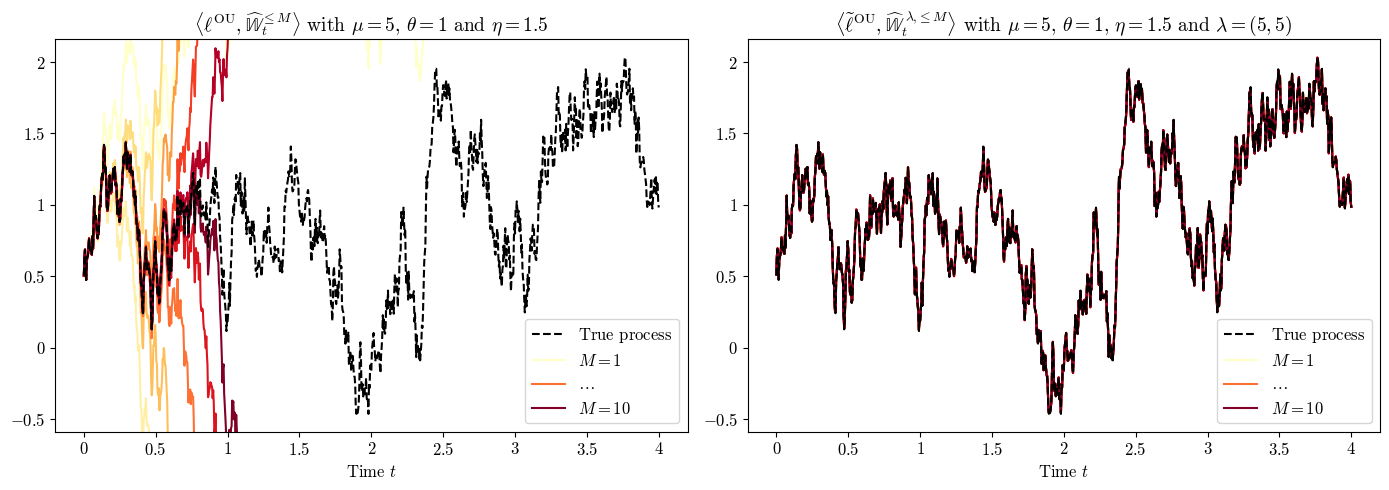

In [31]:
cmap = plt.get_cmap("YlOrRd", len(M_values))
norm_ = mcolors.Normalize(vmin=M_values.min(), vmax=M_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm_)
sm.set_array([])

fig, ax = plt.subplots(1, 2, figsize=(14,5))

ax[0].plot(t_main, X_true[idx, len(t_burn):], color="black", zorder=1, linestyle="--", label=r"$\text{True process}$")
lims = ax[0].get_ylim()
for i, M in enumerate(M_values) :
    color = cmap(norm_(M))
    if i == 0 or i == len(M_values) - 1: 
        ax[0].plot(t_main, traj_sig[i, 0, :], color=color, zorder=0, label=r"$M=$" + fr"${M}$")
    elif i == len(M_values)//2 : 
        ax[0].plot(t_main, traj_sig[i, 0, :], color=color, zorder=0, label=r"$\ldots$")
    else : 
        ax[0].plot(t_main, traj_sig[i, 0, :], color=color, zorder=0)
ax[0].set_ylim(lims)

ax[1].plot(t_main, X_true[idx, len(t_burn):], color="black", zorder=1, linestyle="--", label=r"$\text{True process}$")
lims = ax[1].get_ylim()
for i, M in enumerate(M_values) :
    color = cmap(norm_(M))
    if i == 0 or i == len(M_values) - 1: 
        ax[1].plot(t_main, traj_EFM_sig[i, 0, :], color=color, zorder=0, label=r"$M=$" + fr"${M}$")
    elif i == len(M_values)//2 : 
        ax[1].plot(t_main, traj_EFM_sig[i, 0, :], color=color, zorder=0, label=r"$\ldots$")
    else : 
        ax[1].plot(t_main, traj_EFM_sig[i, 0, :], color=color, zorder=0)
ax[1].set_ylim(lims)


for i in range(2) : 
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(loc="lower right", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 

ax[0].set_title(r"$\left\langle\ell^{\text{OU}}, \widehat{\mathbb{W}}_t^{\leq M} \right\rangle \text{ with } \mu=5, \,\theta=1 \text{ and } \eta=1.5$", fontsize=14)
ax[1].set_title(r"$\left\langle\widetilde{\ell}^{\text{OU}}, \widehat{\mathbb{W}}_t^{\,\,\lambda,\!\leq M} \right\rangle \text{ with } \mu=5, \,\theta=1,\, \eta=1.5 \text{ and } \lambda=(5,5)$", fontsize=14)
plt.tight_layout()
plt.show()

## II. Signature representation of an Langevin-type process

In [4]:
T = 4
T0 = -4
n1 = 500
n2 = T * 365 * 5
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0)

In [5]:
mu, theta, p, eta = 100, 0, 3, 1

In [22]:
import time 
M = 10
start = time.time()
shuffle_table = get_shuffle_table(M, d=2)
print(time.time()-start)

9.753684043884277


In [23]:
X_true = simulate_Langevin_Euler(0.0, mu, theta, eta, paths, p=p)
x = X_true[0, len(t_burn)]
x

np.float64(-0.3223908999679469)

In [24]:
lambd = jnp.array([20.0, 20.0])
start = time.time()
l =  compute_l_EFM_Langevin(lambd, mu, eta, M, p, shuffle_table)
EFM_sig = compute_EFM_signature_one_path(paths[0], M, t_grid, lambd)
traj_EFM_sig = (EFM_sig @ l).T
print(time.time()-start)

12.374759912490845


In [25]:
l = compute_l_EFM_Langevin(jnp.array([0.0, 0.0]), mu, eta, M, p, shuffle_table, x=x)
sig = compute_signature(paths[:, len(t_burn):, :], M)
traj_sig = (sig @ l).T

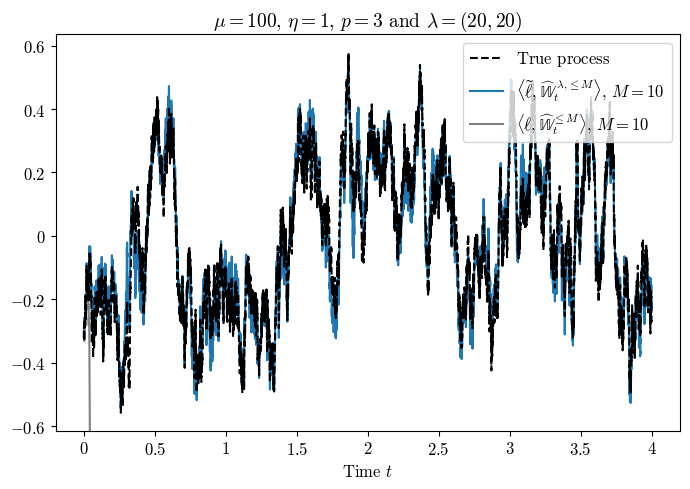

In [26]:
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(t_main, X_true[0, len(t_burn):], color="black", label=r"$\text{True process}$", linestyle="--", zorder=1)
lims = ax.get_ylim()
ax.plot(t_main, traj_EFM_sig, zorder=0, label=r"$\left\langle\widetilde{\ell}, \widehat{\mathbb{W}}_t^{\,\,\lambda,\!\leq M} \right\rangle,\, M=10$")
ax.plot(t_main, traj_sig[0], zorder=0, color="gray", label=r"$\left\langle\ell, \widehat{\mathbb{W}}_t^{\leq M} \right\rangle,\, M=10$")
ax.set_ylim(lims)
ax.legend(fontsize=12)

ax.set_xlabel(r"$\text{Time }t$", fontsize=12)
ax.legend(loc="upper right", fontsize=12)
ax.xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax.yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax.tick_params(axis='both', labelsize=12) 

ax.set_title(r"$\mu=100, \,\eta=1,\, p=3 \text{ and } \lambda=(20, 20)$", fontsize=14)

plt.tight_layout()
plt.show()

## III. Learning stochastic dynamics with signatures

### III.1. Different representations of an Ornstein-Uhlenbeck proceess

In [255]:
T = 4
T0 = -4
n1 = 500
n2 = T * 365 * 10 
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0, seed=42)

In [256]:
mu, theta, p, eta, M = 10, 0, 1, 1, 6

In [257]:
lambd_OU = 2.4
lambd_EFM = 2.4

In [258]:
n_words = number_of_words(M, 2)
zeros = jnp.zeros(n_words)
e0 = Tensor(array=zeros.at[2].set(1.0), M=M, d=2)

In [259]:
X_true = simulate_Langevin_Euler(0.0, lambd_OU, theta, eta, paths)
x = X_true[0, len(t_burn)]
path_OU = np.stack([t_grid, X_true[0]]).T
sig_OU = compute_signature(path_OU[None, len(t_burn):, :], M)
traj_OU_sig = (sig_OU @ e0).T
x

np.float64(-0.015269279727731476)

In [260]:
EFM_sig = compute_EFM_signature_one_path(paths[0], M, t_grid, lambd_EFM)
traj_EFM_sig = (EFM_sig @ e0).T

In [261]:
sig_W = compute_signature(paths[:, len(t_burn):, :], M)
traj_W_sig = (sig_W @ e0).T

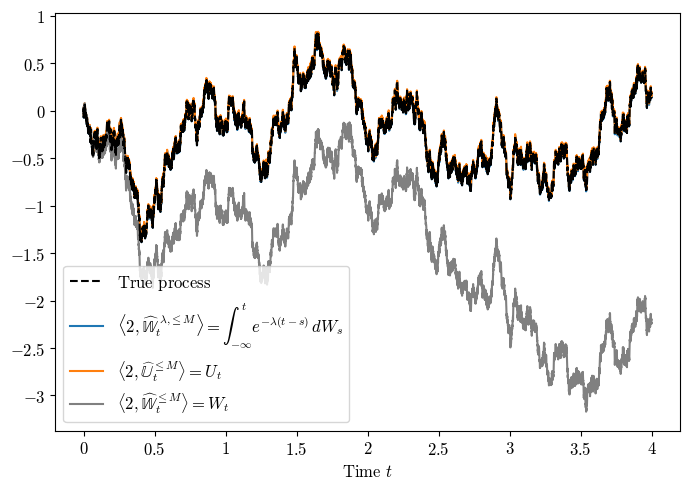

In [285]:
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(t_main, X_true[0, len(t_burn):], color="black", label=r"$\text{True process}$", linestyle="--", zorder=1)
lims = ax.get_ylim()
ax.plot(t_main, traj_EFM_sig, zorder=0, label=r"$\left\langle2, \widehat{\mathbb{W}}_t^{\,\,\lambda,\!\leq M} \right\rangle =\int_{-\infty}^t e^{-\lambda(t-s)}\, dW_s$")
ax.plot(t_main, traj_OU_sig[0], zorder=0, color="tab:orange", label = r"$\left\langle \mathbf{2}, \widehat{\mathbb{U}}_t^{\leq M} \right\rangle = U_t$")
ax.plot(t_main, traj_W_sig[0], zorder=0, color="gray", label=r"$\left\langle2, \widehat{\mathbb{W}}_t^{\leq M} \right\rangle = W_t$")

ax.set_xlabel(r"$\text{Time }t$", fontsize=12)
ax.legend(loc="lower left", fontsize=12)
ax.xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax.yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax.tick_params(axis='both', labelsize=12) 

plt.tight_layout()
plt.show()

### III.2. Regression

#### III.2.1. Ornstein-Uhlenbeck signal 

##### III.2.1.1. Regression

In [7]:
T = 4
T0 = -4
n1 = 500
n2 = T * 365 * 10 
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0, seed=42)

In [8]:
mu, theta, p, eta, M = 2.4, 0, 1, 1, 6

In [9]:
lambd_OU = 2.4
lambd_EFM = 2.4

In [10]:
X_true = simulate_Langevin_Euler(0.0, lambd_OU, theta, eta, paths)
x = X_true[0, len(t_burn)]
path_OU = np.stack([t_grid, X_true[0]]).T
sig_OU = compute_signature(path_OU[None, len(t_burn):, :], M)

sig_EFM = compute_EFM_signature_one_path(paths[0], M, t_grid, lambd_EFM)
sig_W = compute_signature(paths[:, len(t_burn):, :], M)

In [11]:
idx_train = 365 * 10   # 1 year 
idx_val = 365 * 10 * 2 # 2 years 

Y = X_true[0, len(t_burn):]

In [12]:
sig_OU[:, :, 0].shape, sig_EFM.shape, sig_W[:, :, 0].shape

((127, 14601), (127, 14601), (127, 14601))

In [13]:
start = time.time() 
model_OU, Y_OU, rmse_OU, _ = regression_ElasticNet(Y, sig_OU[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("ElasticNet: ", time.time()-start, " seconds, RMSE: ", rmse_OU) 
start = time.time() 
model_OU_Ridge, Y_OU_Ridge, rmse_OU_Ridge, _ = regression_Ridge(Y, sig_OU[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("Ridge: ", time.time()-start, " seconds, RMSE: ", rmse_OU_Ridge) 

ElasticNet:  34.72961211204529  seconds, RMSE:  0.7591901711090926
Ridge:  0.9028213024139404  seconds, RMSE:  0.002693924074597557


In [14]:
start = time.time() 
model_EFM, Y_EFM, rmse_EFM, _ = regression_ElasticNet(Y, sig_EFM, M, idx_train, idx_val, verbose=False) 
print("ElasticNet: ", time.time()-start, " seconds, RMSE: ", rmse_EFM) 
start = time.time() 
model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge, _ = regression_Ridge(Y, sig_EFM, M, idx_train, idx_val, verbose=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge) 

ElasticNet:  0.15226387977600098  seconds, RMSE:  0.0002496149216548607
Ridge:  1.0496509075164795  seconds, RMSE: 0.0002345059201009738


In [15]:
start = time.time() 
model_W, Y_W, rmse_W, _ = regression_ElasticNet(Y, sig_W[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("ElasticNet: ", time.time()-start, " seconds, RMSE: ", rmse_W) 
start = time.time() 
model_W_Ridge, Y_W_Ridge, rmse_W_Ridge, _ = regression_Ridge(Y, sig_W[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_W_Ridge) 

ElasticNet:  15.927395820617676  seconds, RMSE:  8.502111851032875
Ridge:  0.9383690357208252  seconds, RMSE: 9.217513635468642


In [16]:
coef_W = get_full_coef(model_W)
coef_OU = get_full_coef(model_OU)
coef_EFM = get_full_coef(model_EFM)

l_W = Tensor(array=jnp.asarray(coef_W), M=M, d=2)
l_OU = Tensor(array=jnp.asarray(coef_OU), M=M, d=2)
l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)

In [17]:
coef_W = get_full_coef(model_W_Ridge)
coef_OU = get_full_coef(model_OU_Ridge)
coef_EFM = get_full_coef(model_EFM_Ridge)

l_W_Ridge = Tensor(array=jnp.asarray(coef_W), M=M, d=2)
l_OU_Ridge = Tensor(array=jnp.asarray(coef_OU), M=M, d=2)
l_EFM_Ridge = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)

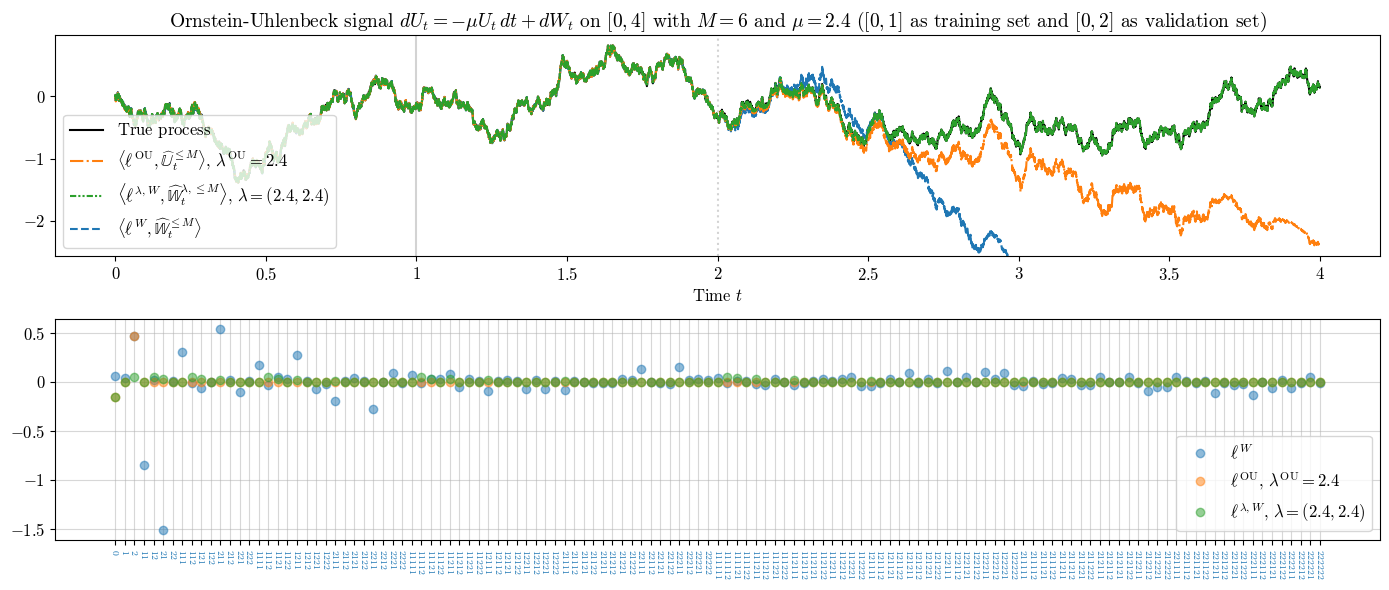

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(14, 6))
ax[0].axvline(1, color="lightgray", zorder=0)
ax[0].axvline(2, color="lightgray", linestyle=":", zorder=0)
ax[0].plot(t_main, Y, color="black", label=r"$\text{True process}$", zorder=0)
ax[0].plot(t_main, Y_OU, color="tab:orange", linestyle="-.", label=r"$\left\langle \ell^{\text{OU}}, \widehat{\mathbb{U}}_t^{\leq M}\right\rangle,\, \lambda^\text{OU}=2.4$", zorder=1)
ax[0].plot(t_main, Y_EFM, color="tab:green", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\left\langle \ell^{\lambda, W}, \widehat{\mathbb{W}}_t^{\lambda, \leq M}\right\rangle,\, \lambda=(2.4,2.4)$", zorder=1)
lims = ax[0].get_ylim()
ax[0].plot(t_main, Y_W, linestyle="--", color="tab:blue", label=r"$\left\langle \ell^{W}, \widehat{\mathbb{W}}_t^{\leq M}\right\rangle$", zorder=0)
ax[0].set_ylim(lims)

ax[0].set_xlabel(r"$\text{Time }t$", fontsize=12)
ax[0].legend(loc="lower left", fontsize=12)
ax[0].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[0].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax[0].tick_params(axis='both', labelsize=12) 
ax[0].set_title(r"$\text{Ornstein-Uhlenbeck signal }dU_t = -\mu U_t\, dt + dW_t \text{ on }[0,4] \text{ with }M=6 \text{ and } \mu=2.4\text{ (}[0,1] \text{ as training set and }[0,2] \text{ as validation set)}$", fontsize=14)

l_W_Ridge.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\ell^{W}$")
l_OU_Ridge.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\ell^{\text{OU}},\, \lambda^\text{OU}=2.4$")
l_EFM_Ridge.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\ell^{\lambda, W},\, \lambda=(2.4,2.4)$")

plt.tight_layout()
plt.show()

##### III.2.1.2. ElasticNet vs Ridge

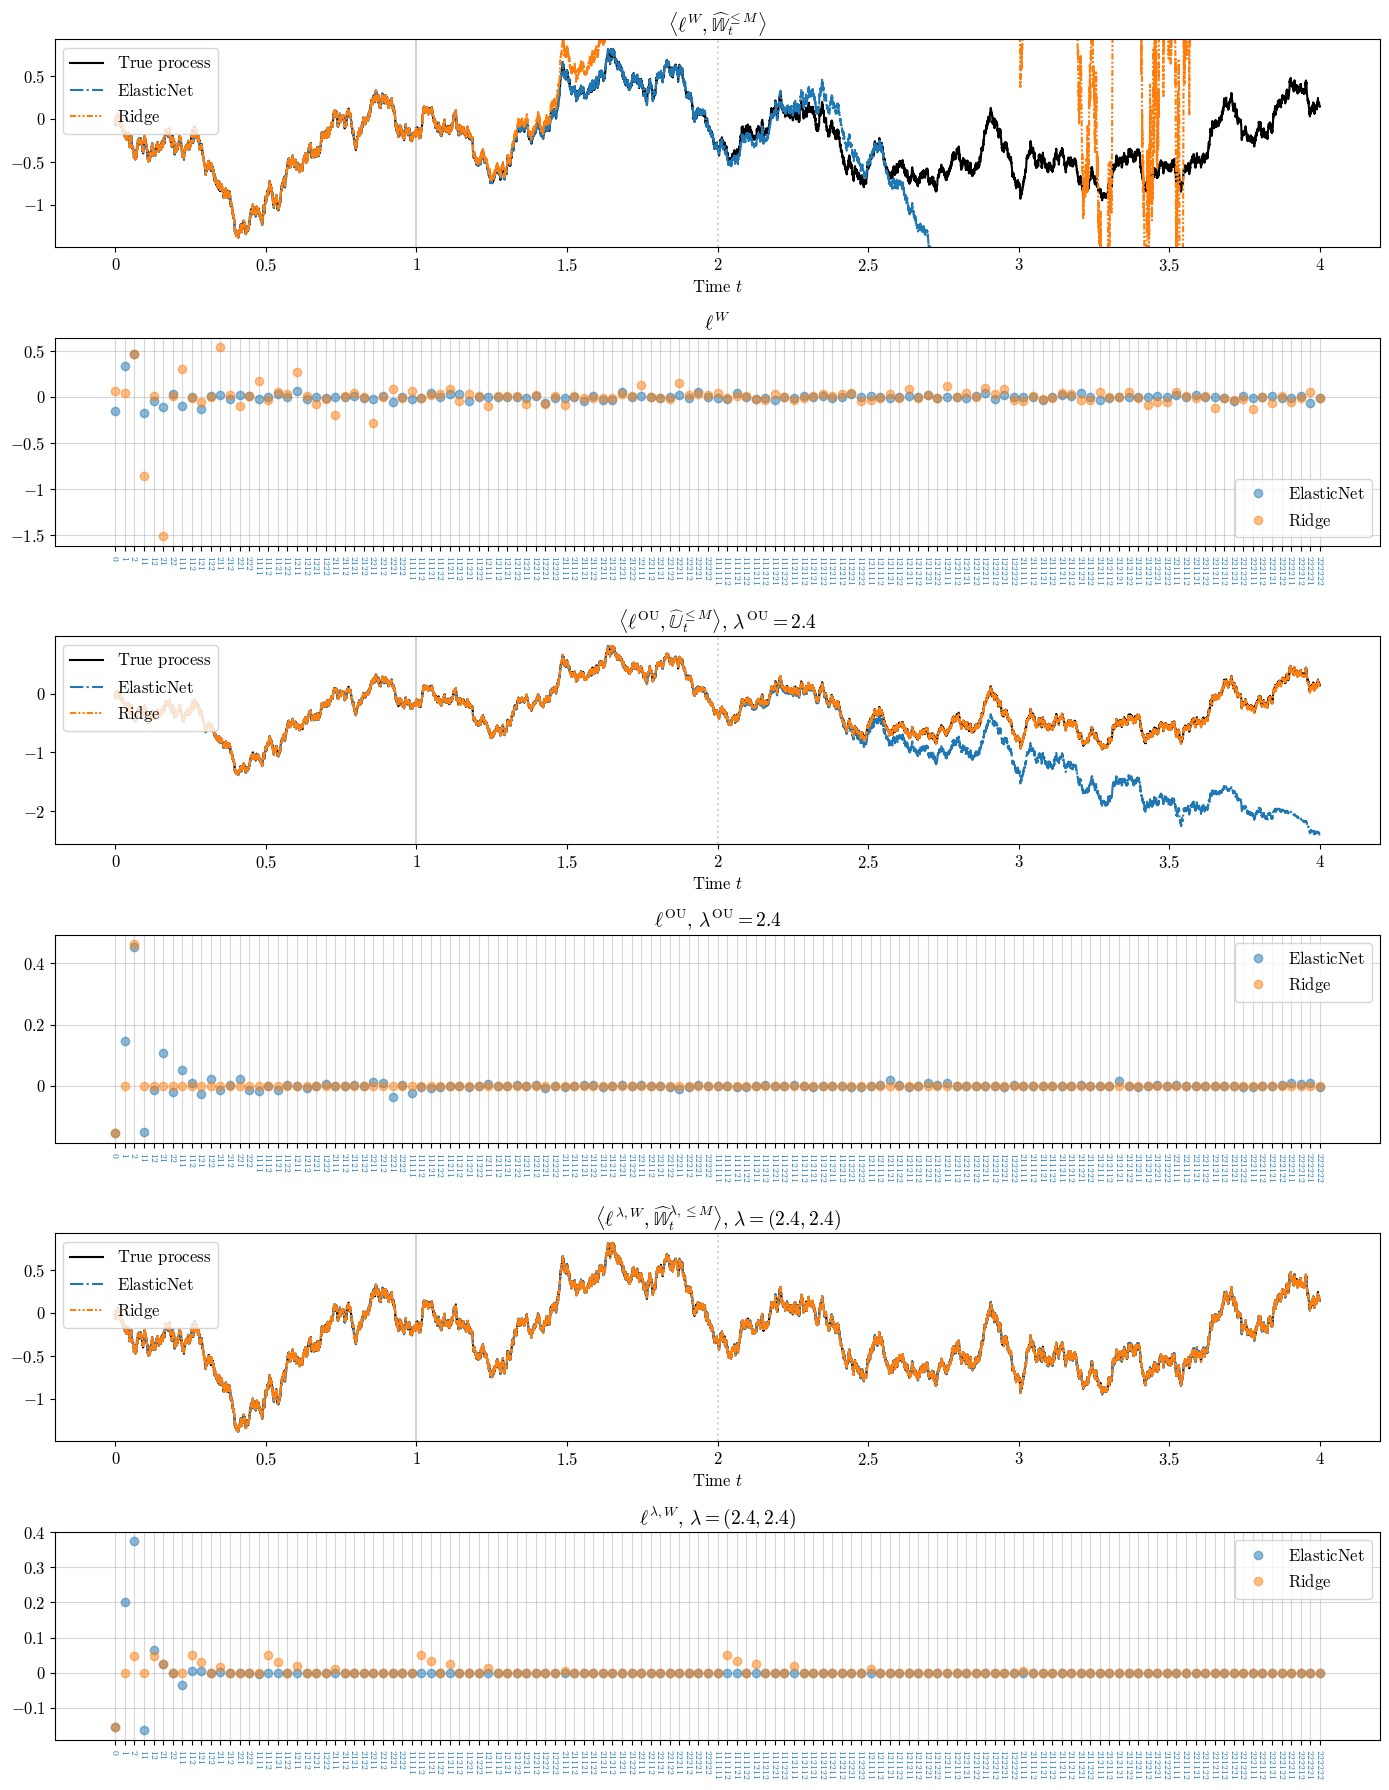

In [25]:
fig, ax = plt.subplots(6, 1, figsize=(14, 3*6))

for i in range(0, 6, 2) : 
    ax[i].axvline(1, color="lightgray", zorder=0)
    ax[i].axvline(2, color="lightgray", linestyle=":", zorder=0)
    ax[i].plot(t_main, Y, color="black", label=r"$\text{True process}$", zorder=0)

lims = ax[0].get_ylim() 
ax[0].plot(t_main, Y_W, zorder=0, label=r"$\text{ElasticNet}$", linestyle="-.")
ax[0].plot(t_main, Y_W_Ridge, zorder=0, label=r"$\text{Ridge}$", linestyle=(0, (3, 1, 1, 1, 1, 1)))
ax[0].set_ylim(lims)
ax[0].set_title(r"$\left\langle \ell^{W}, \widehat{\mathbb{W}}_t^{\leq M}\right\rangle$", fontsize=14)

l_W.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\text{ElasticNet}$")
l_W_Ridge.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\text{Ridge}$")
ax[1].set_title(r"$\ell^{W}$", fontsize=14)

ax[2].plot(t_main, Y_OU, zorder=0, label=r"$\text{ElasticNet}$", linestyle="-.")
ax[2].plot(t_main, Y_OU_Ridge, zorder=0, label=r"$\text{Ridge}$", linestyle=(0, (3, 1, 1, 1, 1, 1)))
ax[2].set_title(r"$\left\langle \ell^{\text{OU}}, \widehat{\mathbb{U}}_t^{\leq M}\right\rangle,\, \lambda^\text{OU}=2.4$", fontsize=14)

l_OU.plot(ax=ax[3], size_x=7, alpha=0.5, label=r"$\text{ElasticNet}$")
l_OU_Ridge.plot(ax=ax[3], size_x=7, alpha=0.5, label=r"$\text{Ridge}$")
ax[3].set_title(r"$\ell^{\text{OU}},\, \lambda^\text{OU}=2.4$", fontsize=14)

ax[4].plot(t_main, Y_EFM, zorder=0, label=r"$\text{ElasticNet}$", linestyle="-.")
ax[4].plot(t_main, Y_EFM_Ridge, zorder=0, label=r"$\text{Ridge}$", linestyle=(0, (3, 1, 1, 1, 1, 1)))
ax[4].set_title(r"$\left\langle \ell^{\lambda, W}, \widehat{\mathbb{W}}_t^{\lambda, \leq M}\right\rangle,\, \lambda=(2.4,2.4)$", fontsize=14)

l_EFM.plot(ax=ax[5], size_x=7, alpha=0.5, label=r"$\text{ElasticNet}$")
l_EFM_Ridge.plot(ax=ax[5], size_x=7, alpha=0.5, label=r"$\text{Ridge}$")
ax[5].set_title(r"$\ell^{\lambda, W},\, \lambda=(2.4,2.4)$", fontsize=14)

for i in range(0, 6, 2) : 
    ax[i].legend(loc="upper left", fontsize=12)
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 
    
plt.tight_layout()
plt.show()

##### III.2.1.3. The influence of $\boldsymbol{\lambda}=(\lambda, \lambda)$

In [48]:
coarse = np.linspace(0, 10, 20)
fine = np.linspace(0.8 * 2.4, 1.2 * 2.4, 10)

lambda_values = np.unique(np.concatenate([coarse, fine]))
model_EFM_values, Y_EFM_values, rmse_EFM_values = [], [], []
model_EFM_values_Ridge, Y_EFM_values_Ridge, rmse_EFM_values_Ridge = [], [], []

for lambd in tqdm(lambda_values) : 
    sig_EFM = compute_EFM_signature_one_path(paths[0], M, t_grid, lambd)
    model_EFM, Y_EFM, rmse_EFM, _ = regression_ElasticNet(Y, sig_EFM, M, idx_train, idx_val, verbose=False) 
    model_EFM_values.append(model_EFM)
    Y_EFM_values.append(Y_EFM)
    rmse_EFM_values.append(rmse_EFM)
    model_EFM, Y_EFM, rmse_EFM, _ = regression_Ridge(Y, sig_EFM, M, idx_train, idx_val, verbose=False) 
    model_EFM_values_Ridge.append(model_EFM)
    Y_EFM_values_Ridge.append(Y_EFM)
    rmse_EFM_values_Ridge.append(rmse_EFM)

100%|███████████████████████████████████████████| 30/30 [13:19<00:00, 26.65s/it]


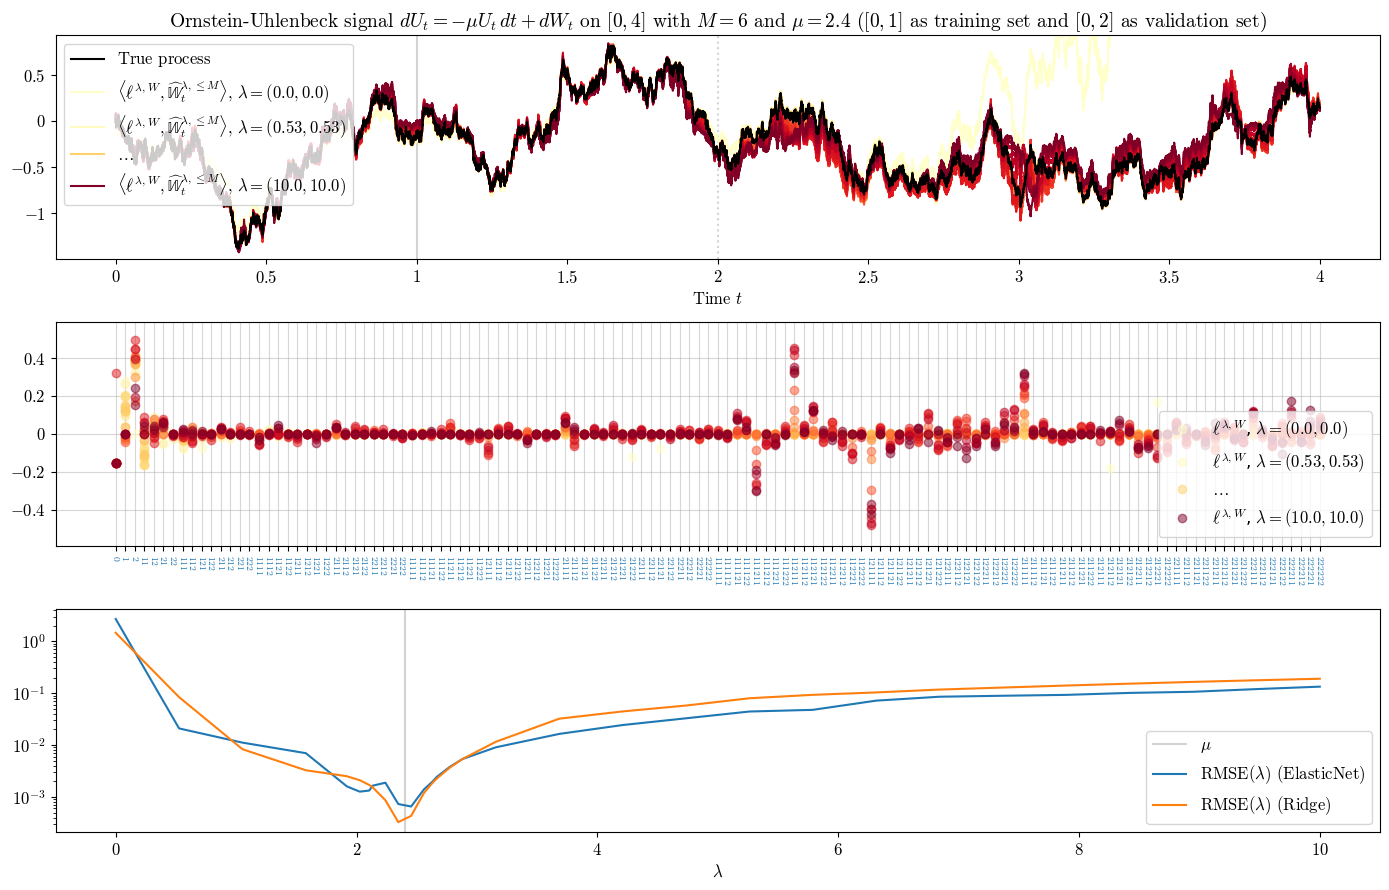

In [54]:
fig, ax = plt.subplots(3, 1, figsize=(14, 9))
ax[0].axvline(1, color="lightgray", zorder=0)
ax[0].axvline(2, color="lightgray", linestyle=":", zorder=0)
ax[0].plot(t_main, Y, color="black", label=r"$\text{True process}$", zorder=1)

cmap = plt.get_cmap("YlOrRd", len(lambda_values))
norm = mcolors.Normalize(vmin=lambda_values.min(), vmax=lambda_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

lims = ax[0].get_ylim()

for i, lambd in enumerate(lambda_values) : 
    color = cmap(norm(lambd))
    if i <= 1 or i == len(lambda_values)-1 : 
        ax[0].plot(t_main, Y_EFM_values[i], color=color, zorder=0, label=r"$\left\langle \ell^{\lambda, W}, \widehat{\mathbb{W}}_t^{\lambda, \leq M}\right\rangle,\,$" + fr"$\lambda={(float(np.round(lambd, 2)), float(np.round(lambd, 2)))}$")     
        coef_EFM = get_full_coef(model_EFM_values[i])
        l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)
        l_EFM.plot(ax=ax[1], size_x=7, alpha=0.5, color=color, label=r"$\ell^{\lambda, W}$, "+fr"$\lambda={(float(np.round(lambd, 2)), float(np.round(lambd, 2)))}$")  

    elif i == len(lambda_values)//2 : 
        ax[0].plot(t_main, Y_EFM_values[i], color=color, zorder=0, label=fr"$\ldots$")     
        coef_EFM = get_full_coef(model_EFM_values[i])
        l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)
        l_EFM.plot(ax=ax[1], size_x=7, alpha=0.5, color=color, label=fr"$\ldots$")
    else : 
        ax[0].plot(t_main, Y_EFM_values[i], color=color, zorder=0)     
        coef_EFM = get_full_coef(model_EFM_values[i])
        l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)
        l_EFM.plot(ax=ax[1], size_x=7, alpha=0.5, color=color)

ax[0].set_ylim(lims)
ax[0].set_xlabel(r"$\text{Time }t$", fontsize=12)
ax[0].legend(loc="upper left", fontsize=12)
ax[0].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[0].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax[0].tick_params(axis='both', labelsize=12) 
ax[0].set_title(r"$\text{Ornstein-Uhlenbeck signal }dU_t = -\mu U_t\, dt + dW_t \text{ on }[0,4] \text{ with }M=6 \text{ and } \mu=2.4\text{ (}[0,1] \text{ as training set and }[0,2] \text{ as validation set)}$", fontsize=14)
ax[1].legend(loc="lower right", fontsize=12)

ax[1].set_ylim(-0.59, 0.59)

ax[2].axvline(lambd_OU, color="lightgray", label=r"$\mu$")
ax[2].semilogy(lambda_values, rmse_EFM_values, label=r"$\text{RMSE}(\lambda) \text{ (ElasticNet)}$", color="tab:blue")
ax[2].semilogy(lambda_values, rmse_EFM_values_Ridge, label=r"$\text{RMSE}(\lambda) \text{ (Ridge)}$", color="tab:orange")
ax[2].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[2].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"$10^{{{int(np.log10(y))}}}$"))
ax[2].tick_params(axis='both', labelsize=12) 
ax[2].set_xlabel(r"$\lambda$", fontsize=12)
ax[2].legend(loc = "lower right", fontsize=12)

plt.tight_layout()
plt.show()

#### III.2.2. Lanvegin signal 

##### III.2.2.1. Regression

In [68]:
T = 4
T0 = -4
n1 = 500
n2 = T * 365 * 10 
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0, seed=1)

In [69]:
mu, theta, eta, p, M = 10, 0, 1, 5, 6

In [70]:
lambd_OU = 2.1
lambd_EFM = 2.4

In [71]:
X_true = simulate_Langevin_Euler(0.0, mu, theta, eta, paths, p=p)
x = X_true[0, len(t_burn)]
X_OU = simulate_Langevin_Euler(0.0, lambd_OU, theta, eta, paths)
path_OU = np.stack([t_grid, X_OU[0]]).T
sig_OU = compute_signature(path_OU[None, len(t_burn):, :], M)

sig_EFM = compute_EFM_signature_one_path(paths[0], M, t_grid, lambd_EFM)
sig_W = compute_signature(paths[:, len(t_burn):, :], M)

In [72]:
idx_train = 365 * 10   # 1 year 
idx_val = 365 * 10 * 2 # 2 years 

Y = X_true[0, len(t_burn):]

In [73]:
start = time.time() 
model_OU, Y_OU, rmse_OU, _ = regression_ElasticNet(Y, sig_OU[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("ElasticNet: ", time.time()-start, " seconds, RMSE: ", rmse_OU) 
start = time.time() 
model_OU_Ridge, Y_OU_Ridge, rmse_OU_Ridge, _ = regression_Ridge(Y, sig_OU[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("Ridge: ", time.time()-start, " seconds, RMSE: ", rmse_OU_Ridge) 

ElasticNet:  8.167370796203613  seconds, RMSE:  0.2501403533840239
Ridge:  0.9072530269622803  seconds, RMSE:  35.98435993837331


In [74]:
start = time.time() 
model_EFM, Y_EFM, rmse_EFM, _ = regression_ElasticNet(Y, sig_EFM, M, idx_train, idx_val, verbose=False) 
print("ElasticNet: ", time.time()-start, " seconds, RMSE: ", rmse_EFM) 
start = time.time() 
model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge, _ = regression_Ridge(Y, sig_EFM, M, idx_train, idx_val, verbose=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge) 

ElasticNet:  30.812413930892944  seconds, RMSE:  0.04853861807420187
Ridge:  1.0473473072052002  seconds, RMSE: 1.2490588047120037


In [75]:
start = time.time() 
model_W, Y_W, rmse_W, _ = regression_ElasticNet(Y, sig_W[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("ElasticNet: ", time.time()-start, " seconds, RMSE: ", rmse_W) 
start = time.time() 
model_W_Ridge, Y_W_Ridge, rmse_W_Ridge, _ = regression_Ridge(Y, sig_W[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_W_Ridge) 

ElasticNet:  52.75823187828064  seconds, RMSE:  6.525938307508744
Ridge:  1.0227458477020264  seconds, RMSE: 40.99353326468169


In [79]:
coef_W = get_full_coef(model_W)
coef_OU = get_full_coef(model_OU)
coef_EFM = get_full_coef(model_EFM)

l_W = Tensor(array=jnp.asarray(coef_W), M=M, d=2)
l_OU = Tensor(array=jnp.asarray(coef_OU), M=M, d=2)
l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)

In [80]:
coef_W = get_full_coef(model_W_Ridge)
coef_OU = get_full_coef(model_OU_Ridge)
coef_EFM = get_full_coef(model_EFM_Ridge)

l_W_Ridge = Tensor(array=jnp.asarray(coef_W), M=M, d=2)
l_OU_Ridge = Tensor(array=jnp.asarray(coef_OU), M=M, d=2)
l_EFM_Ridge = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)

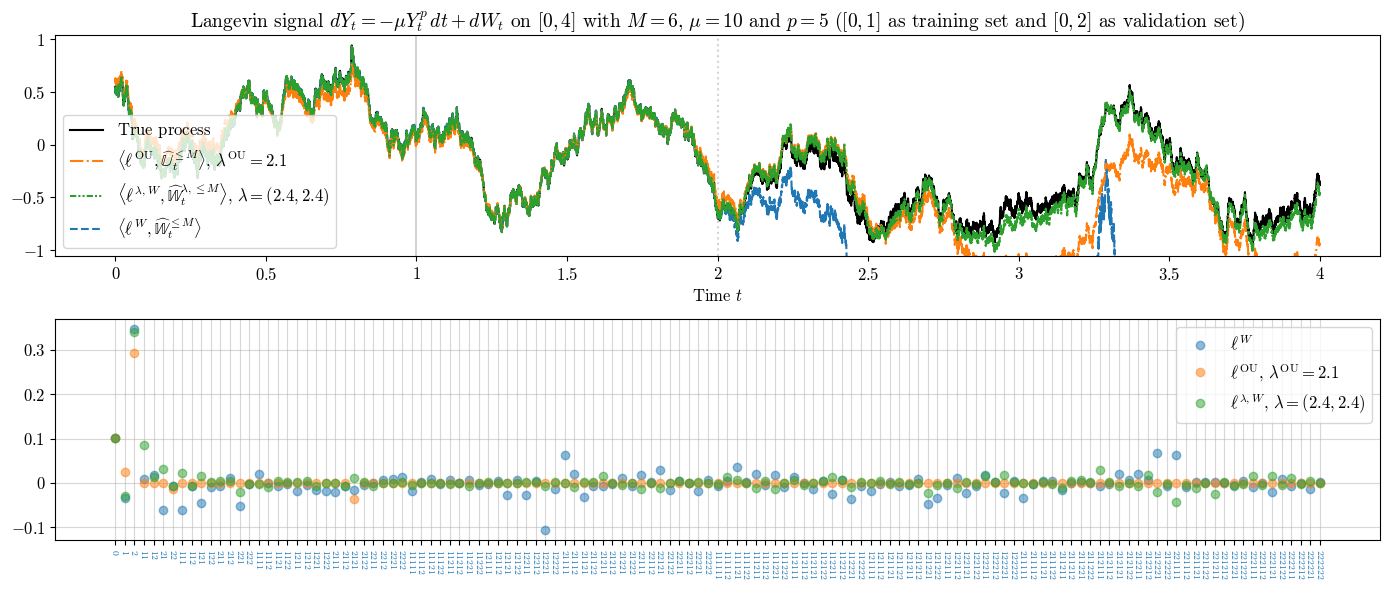

In [85]:
fig, ax = plt.subplots(2, 1, figsize=(14, 6))
ax[0].axvline(1, color="lightgray", zorder=0)
ax[0].axvline(2, color="lightgray", linestyle=":", zorder=0)
ax[0].plot(t_main, Y, color="black", label=r"$\text{True process}$", zorder=0)
lims = ax[0].get_ylim()
ax[0].plot(t_main, Y_OU, color="tab:orange", linestyle="-.", label=r"$\left\langle \ell^{\text{OU}}, \widehat{\mathbb{U}}_t^{\leq M}\right\rangle,\, \lambda^\text{OU}=2.1$", zorder=1)
ax[0].plot(t_main, Y_EFM, color="tab:green", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\left\langle \ell^{\lambda, W}, \widehat{\mathbb{W}}_t^{\lambda, \leq M}\right\rangle,\, \lambda=(2.4,2.4)$", zorder=1)
ax[0].plot(t_main, Y_W, linestyle="--", color="tab:blue", label=r"$\left\langle \ell^{W}, \widehat{\mathbb{W}}_t^{\leq M}\right\rangle$", zorder=0)
ax[0].set_ylim(lims)

ax[0].set_xlabel(r"$\text{Time }t$", fontsize=12)
ax[0].legend(loc="lower left", fontsize=12)
ax[0].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[0].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax[0].tick_params(axis='both', labelsize=12) 
ax[0].set_title(r"$\text{Langevin signal }dY_t = -\mu Y_t^p\, dt + dW_t \text{ on }[0,4] \text{ with }M=6,\, \mu=10 \text{ and } p=5\text{ (}[0,1] \text{ as training set and }[0,2] \text{ as validation set)}$", fontsize=14)

l_W.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\ell^{W}$")
l_OU.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\ell^{\text{OU}},\, \lambda^\text{OU}=2.1$")
l_EFM.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\ell^{\lambda, W},\, \lambda=(2.4,2.4)$")
ax[1].legend(loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()

##### III.2.2.2. ElasticNet vs Ridge 

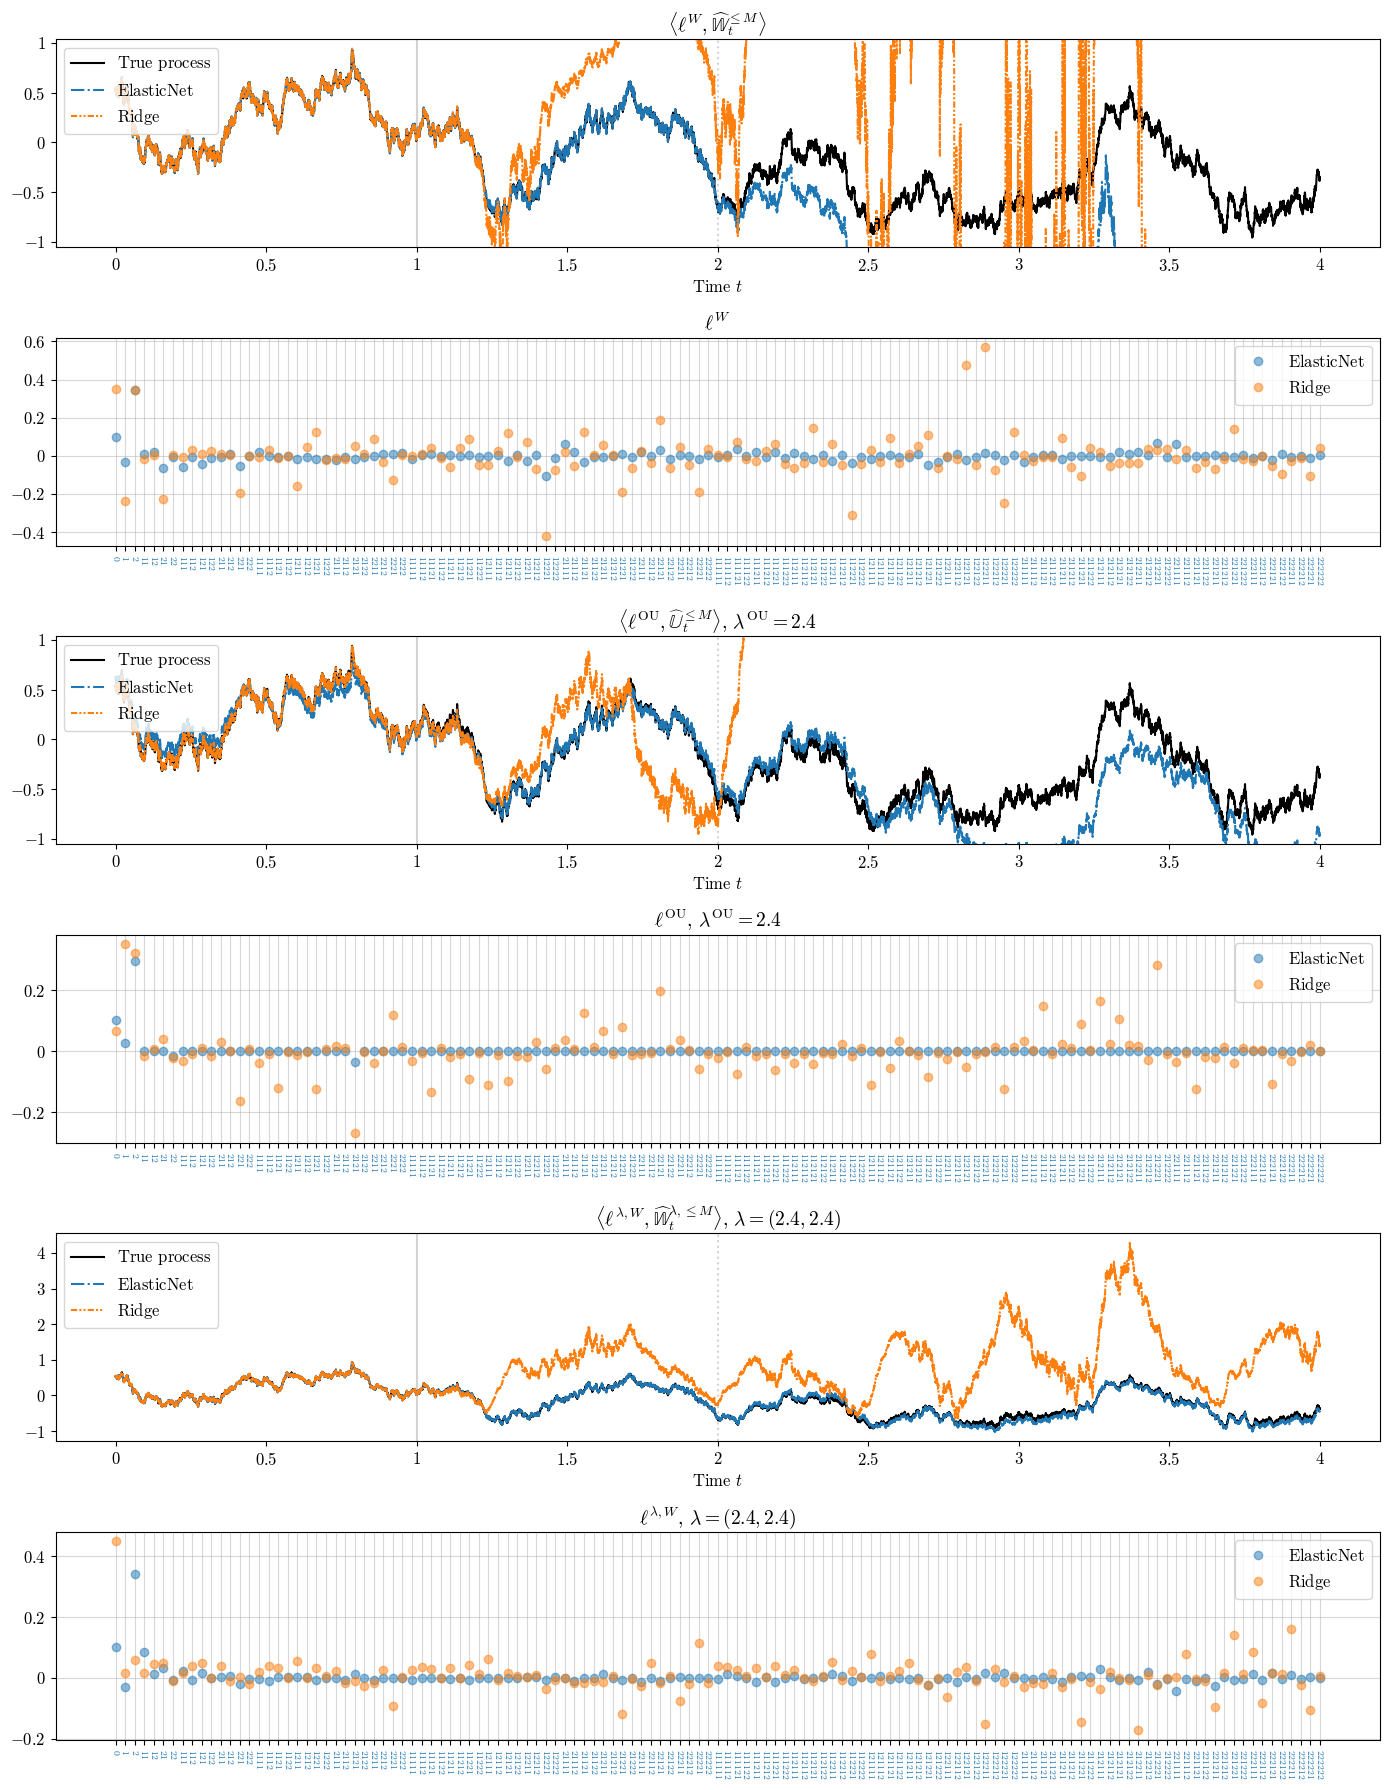

In [89]:
fig, ax = plt.subplots(6, 1, figsize=(14, 3*6))

for i in range(0, 6, 2) : 
    ax[i].axvline(1, color="lightgray", zorder=0)
    ax[i].axvline(2, color="lightgray", linestyle=":", zorder=0)
    ax[i].plot(t_main, Y, color="black", label=r"$\text{True process}$", zorder=0)

lims = ax[0].get_ylim() 
ax[0].plot(t_main, Y_W, zorder=0, label=r"$\text{ElasticNet}$", linestyle="-.")
ax[0].plot(t_main, Y_W_Ridge, zorder=0, label=r"$\text{Ridge}$", linestyle=(0, (3, 1, 1, 1, 1, 1)))
ax[0].set_ylim(lims)
ax[0].set_title(r"$\left\langle \ell^{W}, \widehat{\mathbb{W}}_t^{\leq M}\right\rangle$", fontsize=14)

l_W.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\text{ElasticNet}$")
l_W_Ridge.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\text{Ridge}$")
ax[1].set_title(r"$\ell^{W}$", fontsize=14)

ax[2].plot(t_main, Y_OU, zorder=0, label=r"$\text{ElasticNet}$", linestyle="-.")
ax[2].plot(t_main, Y_OU_Ridge, zorder=0, label=r"$\text{Ridge}$", linestyle=(0, (3, 1, 1, 1, 1, 1)))
ax[2].set_ylim(lims)
ax[2].set_title(r"$\left\langle \ell^{\text{OU}}, \widehat{\mathbb{U}}_t^{\leq M}\right\rangle,\, \lambda^\text{OU}=2.4$", fontsize=14)

l_OU.plot(ax=ax[3], size_x=7, alpha=0.5, label=r"$\text{ElasticNet}$")
l_OU_Ridge.plot(ax=ax[3], size_x=7, alpha=0.5, label=r"$\text{Ridge}$")
ax[3].set_title(r"$\ell^{\text{OU}},\, \lambda^\text{OU}=2.4$", fontsize=14)

ax[4].plot(t_main, Y_EFM, zorder=0, label=r"$\text{ElasticNet}$", linestyle="-.")
ax[4].plot(t_main, Y_EFM_Ridge, zorder=0, label=r"$\text{Ridge}$", linestyle=(0, (3, 1, 1, 1, 1, 1)))
ax[4].set_title(r"$\left\langle \ell^{\lambda, W}, \widehat{\mathbb{W}}_t^{\lambda, \leq M}\right\rangle,\, \lambda=(2.4,2.4)$", fontsize=14)

l_EFM.plot(ax=ax[5], size_x=7, alpha=0.5, label=r"$\text{ElasticNet}$")
l_EFM_Ridge.plot(ax=ax[5], size_x=7, alpha=0.5, label=r"$\text{Ridge}$")
ax[5].set_title(r"$\ell^{\lambda, W},\, \lambda=(2.4,2.4)$", fontsize=14)

for i in range(0, 6, 2) : 
    ax[i].legend(loc="upper left", fontsize=12)
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 
    
plt.tight_layout()
plt.show()

##### III.2.2.3. The influence of $\boldsymbol{\lambda}=(\lambda, \lambda)$

In [90]:
coarse = np.linspace(0, 10, 20)

lambda_values = np.unique(np.concatenate([coarse, fine]))
model_EFM_values, Y_EFM_values, rmse_EFM_values = [], [], []
model_EFM_values_Ridge, Y_EFM_values_Ridge, rmse_EFM_values_Ridge = [], [], []

for lambd in tqdm(lambda_values) : 
    sig_EFM = compute_EFM_signature_one_path(paths[0], M, t_grid, lambd)
    model_EFM, Y_EFM, rmse_EFM, _ = regression_ElasticNet(Y, sig_EFM, M, idx_train, idx_val, verbose=False) 
    model_EFM_values.append(model_EFM)
    Y_EFM_values.append(Y_EFM)
    rmse_EFM_values.append(rmse_EFM)
    model_EFM, Y_EFM, rmse_EFM, _ = regression_Ridge(Y, sig_EFM, M, idx_train, idx_val, verbose=False) 
    model_EFM_values_Ridge.append(model_EFM)
    Y_EFM_values_Ridge.append(Y_EFM)
    rmse_EFM_values_Ridge.append(rmse_EFM)

100%|███████████████████████████████████████████| 30/30 [18:17<00:00, 36.58s/it]


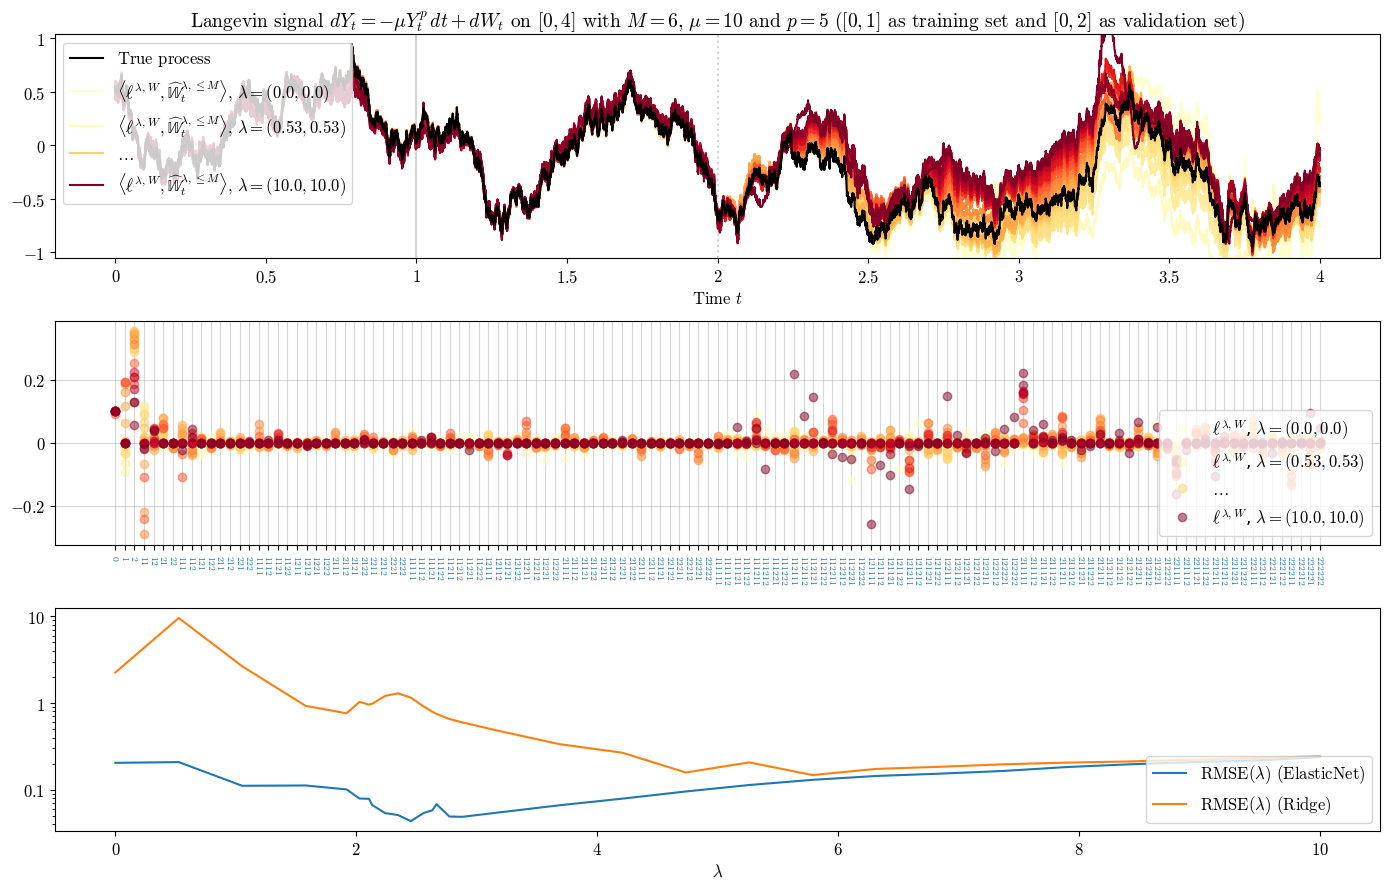

In [94]:
fig, ax = plt.subplots(3, 1, figsize=(14, 9))
ax[0].axvline(1, color="lightgray", zorder=0)
ax[0].axvline(2, color="lightgray", linestyle=":", zorder=0)
ax[0].plot(t_main, Y, color="black", label=r"$\text{True process}$", zorder=1)

cmap = plt.get_cmap("YlOrRd", len(lambda_values))
norm = mcolors.Normalize(vmin=lambda_values.min(), vmax=lambda_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

lims = ax[0].get_ylim()

for i, lambd in enumerate(lambda_values) : 
    color = cmap(norm(lambd))
    if i <= 1 or i == len(lambda_values)-1 : 
        ax[0].plot(t_main, Y_EFM_values[i], color=color, zorder=0, label=r"$\left\langle \ell^{\lambda, W}, \widehat{\mathbb{W}}_t^{\lambda, \leq M}\right\rangle,\,$" + fr"$\lambda={(float(np.round(lambd, 2)), float(np.round(lambd, 2)))}$")     
        coef_EFM = get_full_coef(model_EFM_values[i])
        l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)
        l_EFM.plot(ax=ax[1], size_x=7, alpha=0.5, color=color, label=r"$\ell^{\lambda, W}$, "+fr"$\lambda={(float(np.round(lambd, 2)), float(np.round(lambd, 2)))}$")  

    elif i == len(lambda_values)//2 : 
        ax[0].plot(t_main, Y_EFM_values[i], color=color, zorder=0, label=fr"$\ldots$")     
        coef_EFM = get_full_coef(model_EFM_values[i])
        l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)
        l_EFM.plot(ax=ax[1], size_x=7, alpha=0.5, color=color, label=fr"$\ldots$")
    else : 
        ax[0].plot(t_main, Y_EFM_values[i], color=color, zorder=0)     
        coef_EFM = get_full_coef(model_EFM_values[i])
        l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)
        l_EFM.plot(ax=ax[1], size_x=7, alpha=0.5, color=color)

ax[0].set_ylim(lims)
ax[0].set_xlabel(r"$\text{Time }t$", fontsize=12)
ax[0].legend(loc="upper left", fontsize=12)
ax[0].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[0].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax[0].tick_params(axis='both', labelsize=12) 
ax[0].set_title(r"$\text{Langevin signal }dY_t = -\mu Y_t^p\, dt + dW_t \text{ on }[0,4] \text{ with }M=6,\, \mu=10 \text{ and } p=5\text{ (}[0,1] \text{ as training set and }[0,2] \text{ as validation set)}$", fontsize=14)
ax[1].legend(loc="lower right", fontsize=12)

ax[2].semilogy(lambda_values, rmse_EFM_values, label=r"$\text{RMSE}(\lambda) \text{ (ElasticNet)}$", color="tab:blue")
ax[2].semilogy(lambda_values, rmse_EFM_values_Ridge, label=r"$\text{RMSE}(\lambda) \text{ (Ridge)}$", color="tab:orange")
ax[2].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[2].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax[2].tick_params(axis='both', labelsize=12) 
ax[2].set_xlabel(r"$\lambda$", fontsize=12)
ax[2].legend(loc = "lower right", fontsize=12)

plt.tight_layout()
plt.show()

#### III.2.3. Stationary sinusoidal signal 

##### III.2.3.1. Regression

In [95]:
T = 4
T0 = -4
n1 = 500
n2 = T * 365 * 10 
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0, seed=1)

In [96]:
mu, theta, eta, M = 10, 0, 1, 6

In [97]:
X_true = 1 / np.sqrt(1.01 + np.sin(2*simulate_Langevin_Euler(0.0, mu, theta, eta, paths)))

In [98]:
lambd_OU, lambd_EFM = 5, 5 

In [99]:
X_OU = simulate_Langevin_Euler(0.0, lambd_OU, theta, eta, paths)
path_OU = np.stack([t_grid, X_OU[0]]).T
sig_OU = compute_signature(path_OU[None, len(t_burn):, :], M)
sig_EFM = compute_EFM_signature_one_path(paths[0], M, t_grid, lambd_EFM)
sig_W = compute_signature(paths[:, len(t_burn):, :], M)

In [100]:
idx_train = 365 * 10   # 1 year 
idx_val = 365 * 10 * 2 # 2 years 

Y = X_true[0, len(t_burn):]

In [101]:
start = time.time() 
model_OU, Y_OU, rmse_OU, _ = regression_ElasticNet(Y, sig_OU[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("ElasticNet: ", time.time()-start, " seconds, RMSE: ", rmse_OU) 
start = time.time() 
model_OU_Ridge, Y_OU_Ridge, rmse_OU_Ridge, _ = regression_Ridge(Y, sig_OU[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("Ridge: ", time.time()-start, " seconds, RMSE: ", rmse_OU_Ridge) 

ElasticNet:  34.49902892112732  seconds, RMSE:  17.181982881182986
Ridge:  0.9090290069580078  seconds, RMSE:  7.831138185302122


In [102]:
start = time.time() 
model_EFM, Y_EFM, rmse_EFM, _ = regression_ElasticNet(Y, sig_EFM, M, idx_train, idx_val, verbose=False) 
print("ElasticNet: ", time.time()-start, " seconds, RMSE: ", rmse_EFM) 
start = time.time() 
model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge, _ = regression_Ridge(Y, sig_EFM, M, idx_train, idx_val, verbose=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge) 

ElasticNet:  20.948734045028687  seconds, RMSE:  0.014119352105288294
Ridge:  0.8853237628936768  seconds, RMSE: 0.06611735207666872


In [103]:
start = time.time() 
model_W, Y_W, rmse_W, _ = regression_ElasticNet(Y, sig_W[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("ElasticNet: ", time.time()-start, " seconds, RMSE: ", rmse_W) 
start = time.time() 
model_W_Ridge, Y_W_Ridge, rmse_W_Ridge, _ = regression_Ridge(Y, sig_W[:, :, 0], M, idx_train, idx_val, verbose=False) 
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_W_Ridge) 

ElasticNet:  2.413147211074829  seconds, RMSE:  19.76267434616328
Ridge:  0.8842577934265137  seconds, RMSE: 21.2212952503173


In [104]:
coef_W = get_full_coef(model_W)
coef_OU = get_full_coef(model_OU)
coef_EFM = get_full_coef(model_EFM)

l_W = Tensor(array=jnp.asarray(coef_W), M=M, d=2)
l_OU = Tensor(array=jnp.asarray(coef_OU), M=M, d=2)
l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)

In [105]:
coef_W = get_full_coef(model_W_Ridge)
coef_OU = get_full_coef(model_OU_Ridge)
coef_EFM = get_full_coef(model_EFM_Ridge)

l_W_Ridge = Tensor(array=jnp.asarray(coef_W), M=M, d=2)
l_OU_Ridge = Tensor(array=jnp.asarray(coef_OU), M=M, d=2)
l_EFM_Ridge = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)

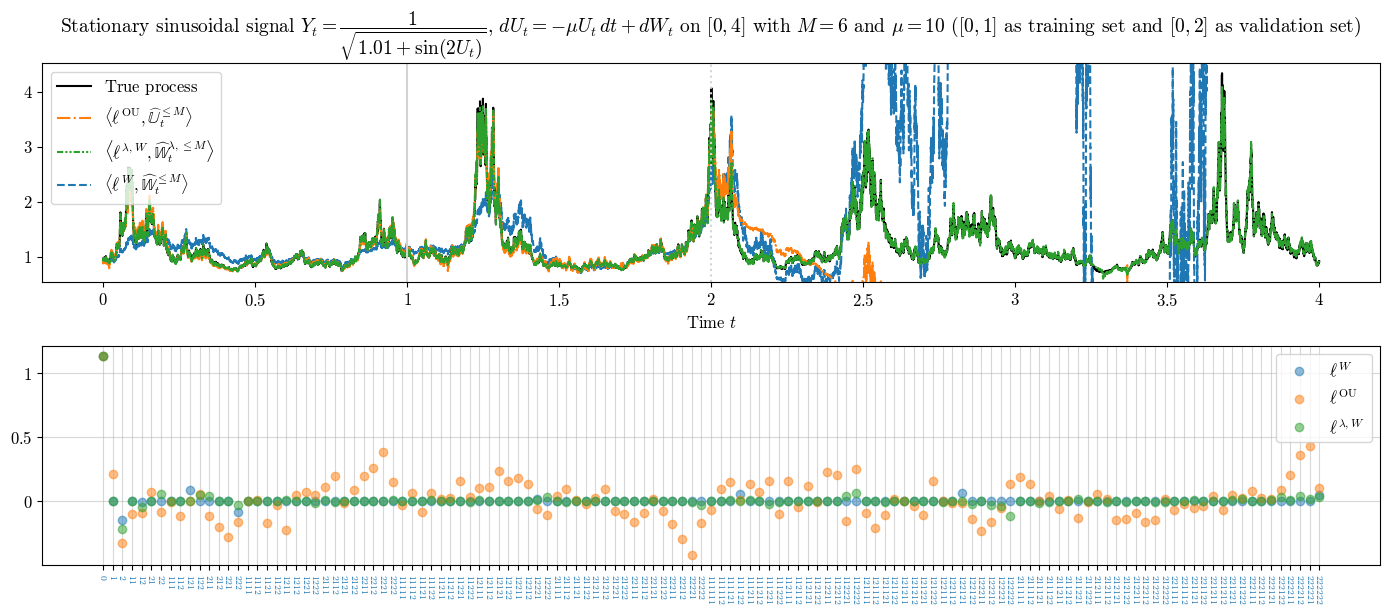

In [110]:
fig, ax = plt.subplots(2, 1, figsize=(14, 6.25))
ax[0].axvline(1, color="lightgray")
ax[0].axvline(2, color="lightgray", linestyle=":")
ax[0].plot(t_main, Y, color="black", label=r"$\text{True process}$", zorder=0)
lims = ax[0].get_ylim()
ax[0].plot(t_main, Y_OU, color="tab:orange", linestyle="-.", label=r"$\left\langle \ell^{\text{OU}}, \widehat{\mathbb{U}}_t^{\leq M}\right\rangle$", zorder=1)
ax[0].plot(t_main, Y_EFM, color="tab:green", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\left\langle \ell^{\lambda, W}, \widehat{\mathbb{W}}_t^{\lambda, \leq M}\right\rangle$", zorder=1)

ax[0].plot(t_main, Y_W, linestyle="--", color="tab:blue", label=r"$\left\langle \ell^{W}, \widehat{\mathbb{W}}_t^{\leq M}\right\rangle$", zorder=0)
ax[0].set_ylim(lims)

ax[0].set_xlabel(r"$\text{Time }t$", fontsize=12)
ax[0].legend(loc="upper left", fontsize=12)
ax[0].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[0].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax[0].tick_params(axis='both', labelsize=12) 
ax[0].set_title(r"$\text{Stationary sinusoidal signal } Y_t = \dfrac{1}{\sqrt{1.01+\sin(2U_t)}},\, dU_t = -\mu U_t\, dt + dW_t\text{ on }[0,4] \text{ with }M=6 \text{ and } \mu=10\text{ (}[0,1] \text{ as training set and }[0,2] \text{ as validation set)}$", fontsize=14)

l_W.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\ell^{W}$")
l_OU.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\ell^{\text{OU}}$")
l_EFM.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\ell^{\lambda, W}$")

plt.tight_layout()
plt.show()

##### III.2.3.2. ElasticNet vs Ridge 

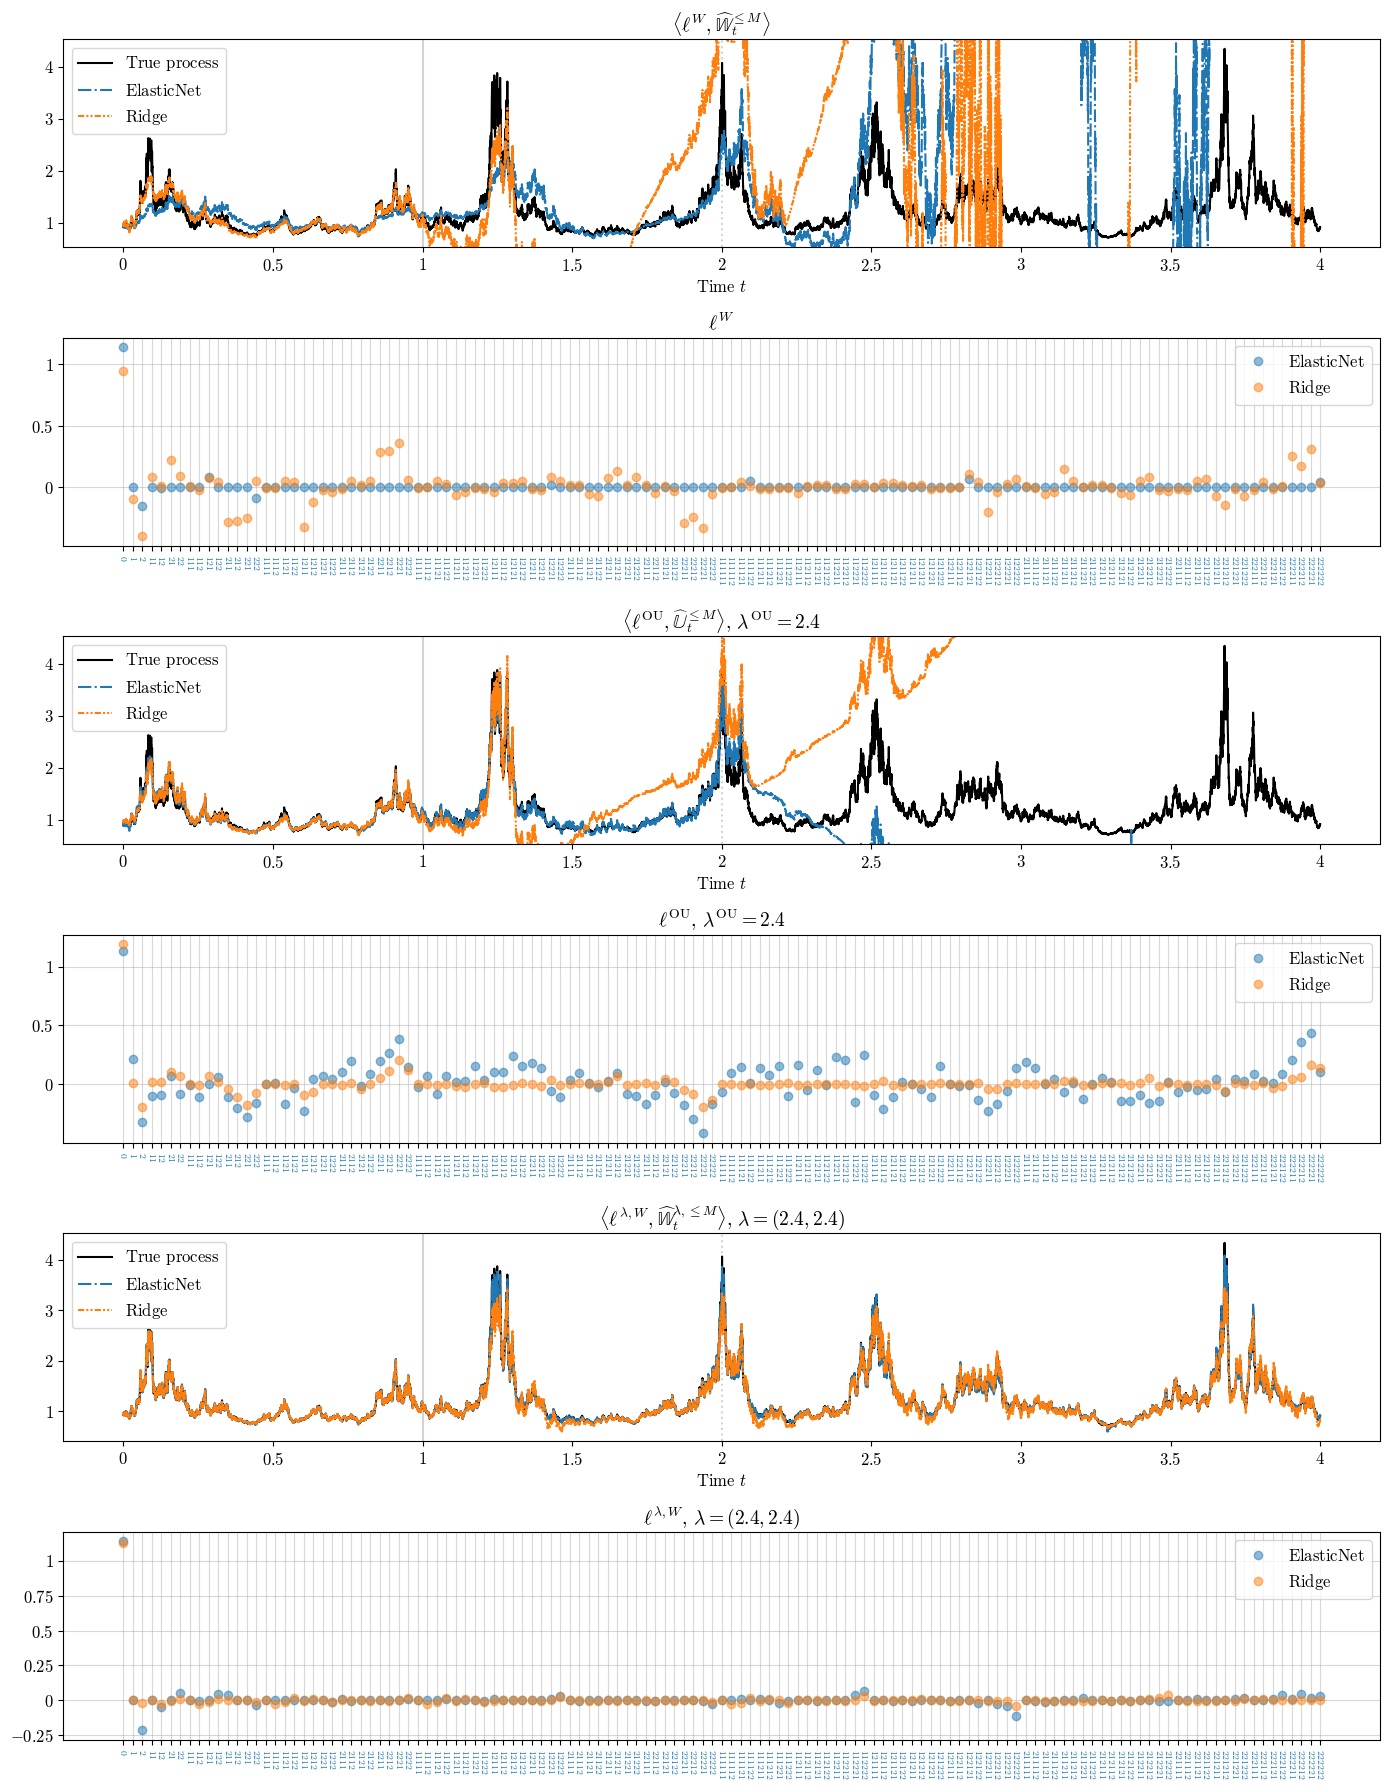

In [114]:
fig, ax = plt.subplots(6, 1, figsize=(14, 3*6))

for i in range(0, 6, 2) : 
    ax[i].axvline(1, color="lightgray", zorder=0)
    ax[i].axvline(2, color="lightgray", linestyle=":", zorder=0)
    ax[i].plot(t_main, Y, color="black", label=r"$\text{True process}$", zorder=0)

lims = ax[0].get_ylim() 
ax[0].plot(t_main, Y_W, zorder=0, label=r"$\text{ElasticNet}$", linestyle="-.")
ax[0].plot(t_main, Y_W_Ridge, zorder=0, label=r"$\text{Ridge}$", linestyle=(0, (3, 1, 1, 1, 1, 1)))
ax[0].set_ylim(lims)
ax[0].set_title(r"$\left\langle \ell^{W}, \widehat{\mathbb{W}}_t^{\leq M}\right\rangle$", fontsize=14)

l_W.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\text{ElasticNet}$")
l_W_Ridge.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\text{Ridge}$")
ax[1].set_title(r"$\ell^{W}$", fontsize=14)

ax[2].plot(t_main, Y_OU, zorder=0, label=r"$\text{ElasticNet}$", linestyle="-.")
ax[2].plot(t_main, Y_OU_Ridge, zorder=0, label=r"$\text{Ridge}$", linestyle=(0, (3, 1, 1, 1, 1, 1)))
ax[2].set_ylim(lims)
ax[2].set_title(r"$\left\langle \ell^{\text{OU}}, \widehat{\mathbb{U}}_t^{\leq M}\right\rangle,\, \lambda^\text{OU}=2.4$", fontsize=14)

l_OU.plot(ax=ax[3], size_x=7, alpha=0.5, label=r"$\text{ElasticNet}$")
l_OU_Ridge.plot(ax=ax[3], size_x=7, alpha=0.5, label=r"$\text{Ridge}$")
ax[3].set_title(r"$\ell^{\text{OU}},\, \lambda^\text{OU}=2.4$", fontsize=14)

ax[4].plot(t_main, Y_EFM, zorder=0, label=r"$\text{ElasticNet}$", linestyle="-.")
ax[4].plot(t_main, Y_EFM_Ridge, zorder=0, label=r"$\text{Ridge}$", linestyle=(0, (3, 1, 1, 1, 1, 1)))
ax[4].set_title(r"$\left\langle \ell^{\lambda, W}, \widehat{\mathbb{W}}_t^{\lambda, \leq M}\right\rangle,\, \lambda=(2.4,2.4)$", fontsize=14)

l_EFM.plot(ax=ax[5], size_x=7, alpha=0.5, label=r"$\text{ElasticNet}$")
l_EFM_Ridge.plot(ax=ax[5], size_x=7, alpha=0.5, label=r"$\text{Ridge}$")
ax[5].set_title(r"$\ell^{\lambda, W},\, \lambda=(2.4,2.4)$", fontsize=14)

for i in range(0, 6, 2) : 
    ax[i].legend(loc="upper left", fontsize=12)
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 
    
plt.tight_layout()
plt.show()

##### III.2.3.3. The influence of $\boldsymbol{\lambda}=(\lambda, \lambda)$

In [116]:
lambda_values = np.linspace(0, 10, 20) 
model_EFM_values, Y_EFM_values, rmse_EFM_values = [], [], []
model_EFM_values_Ridge, Y_EFM_values_Ridge, rmse_EFM_values_Ridge = [], [], []

for lambd in tqdm(lambda_values) : 
    sig_EFM = compute_EFM_signature_one_path(paths[0], M, t_grid, lambd)
    model_EFM, Y_EFM, rmse_EFM, _ = regression_ElasticNet(Y, sig_EFM, M, idx_train, idx_val, verbose=False) 
    model_EFM_values.append(model_EFM)
    Y_EFM_values.append(Y_EFM)
    rmse_EFM_values.append(rmse_EFM)
    model_EFM, Y_EFM, rmse_EFM, _ = regression_Ridge(Y, sig_EFM, M, idx_train, idx_val, verbose=False) 
    model_EFM_values_Ridge.append(model_EFM)
    Y_EFM_values_Ridge.append(Y_EFM)
    rmse_EFM_values_Ridge.append(rmse_EFM)

100%|███████████████████████████████████████████| 20/20 [14:30<00:00, 43.51s/it]


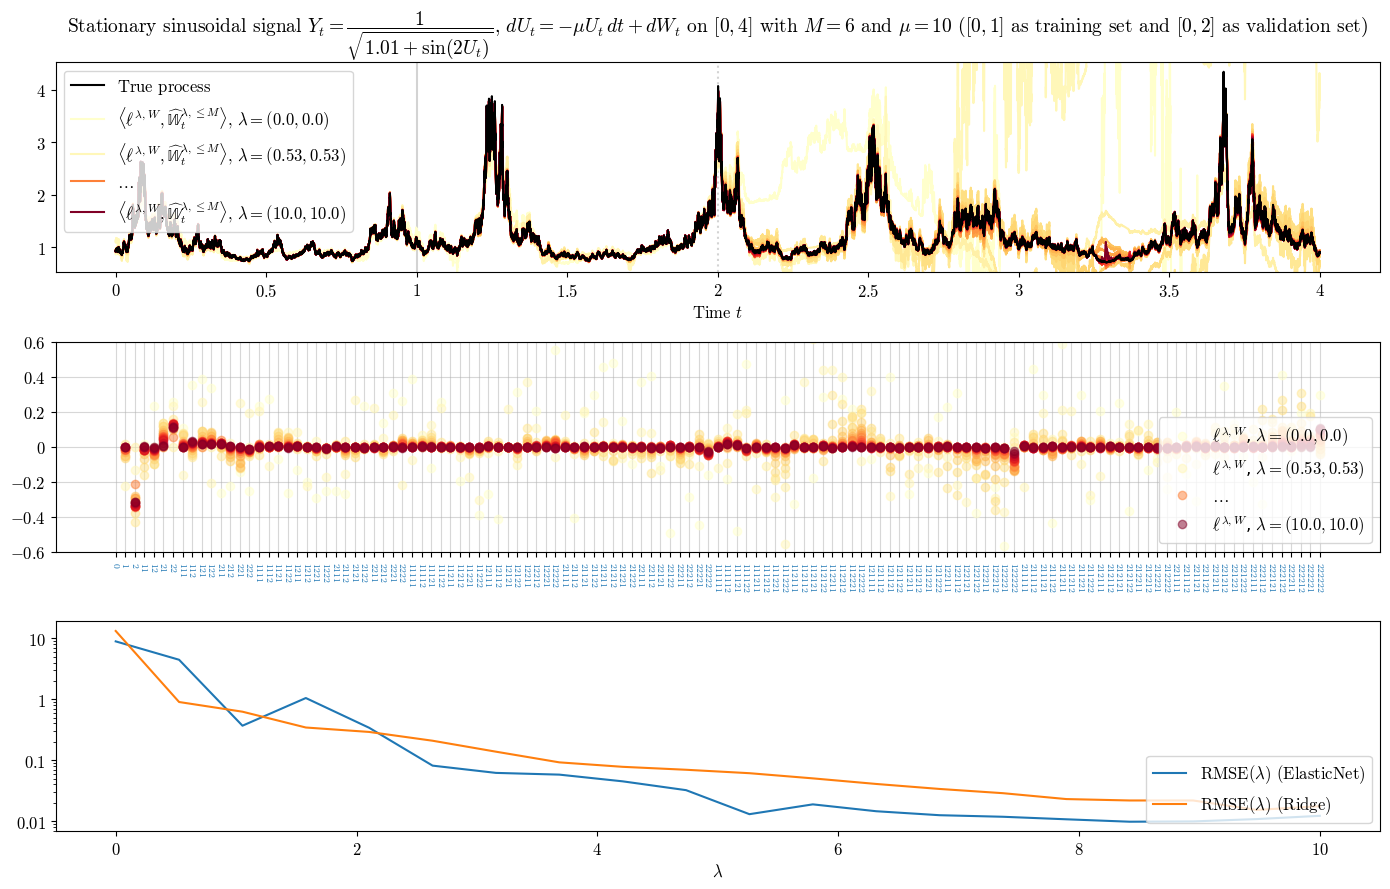

In [122]:
fig, ax = plt.subplots(3, 1, figsize=(14, 9))
ax[0].axvline(1, color="lightgray", zorder=0)
ax[0].axvline(2, color="lightgray", linestyle=":", zorder=0)
ax[0].plot(t_main, Y, color="black", label=r"$\text{True process}$", zorder=1)

cmap = plt.get_cmap("YlOrRd", len(lambda_values))
norm = mcolors.Normalize(vmin=lambda_values.min(), vmax=lambda_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

lims = ax[0].get_ylim()

for i, lambd in enumerate(lambda_values) : 
    color = cmap(norm(lambd))
    if i <= 1 or i == len(lambda_values)-1 : 
        ax[0].plot(t_main, Y_EFM_values[i], color=color, zorder=0, label=r"$\left\langle \ell^{\lambda, W}, \widehat{\mathbb{W}}_t^{\lambda, \leq M}\right\rangle,\,$" + fr"$\lambda={(float(np.round(lambd, 2)), float(np.round(lambd, 2)))}$")     
        coef_EFM = get_full_coef(model_EFM_values[i])
        l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)
        l_EFM.plot(ax=ax[1], size_x=7, alpha=0.5, color=color, label=r"$\ell^{\lambda, W}$, "+fr"$\lambda={(float(np.round(lambd, 2)), float(np.round(lambd, 2)))}$")  

    elif i == len(lambda_values)//2 : 
        ax[0].plot(t_main, Y_EFM_values[i], color=color, zorder=0, label=fr"$\ldots$")     
        coef_EFM = get_full_coef(model_EFM_values[i])
        l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)
        l_EFM.plot(ax=ax[1], size_x=7, alpha=0.5, color=color, label=fr"$\ldots$")
    else : 
        ax[0].plot(t_main, Y_EFM_values[i], color=color, zorder=0)     
        coef_EFM = get_full_coef(model_EFM_values[i])
        l_EFM = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)
        l_EFM.plot(ax=ax[1], size_x=7, alpha=0.5, color=color)

ax[0].set_ylim(lims)
ax[0].set_xlabel(r"$\text{Time }t$", fontsize=12)
ax[0].legend(loc="upper left", fontsize=12)
ax[0].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[0].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax[0].tick_params(axis='both', labelsize=12) 
ax[0].set_title(r"$\text{Stationary sinusoidal signal } Y_t = \dfrac{1}{\sqrt{1.01+\sin(2U_t)}},\, dU_t = -\mu U_t\, dt + dW_t\text{ on }[0,4] \text{ with }M=6 \text{ and } \mu=10\text{ (}[0,1] \text{ as training set and }[0,2] \text{ as validation set)}$", fontsize=14)
ax[1].legend(loc="lower right", fontsize=12)
ax[1].set_ylim(-0.6, 0.6)
ax[2].semilogy(lambda_values, rmse_EFM_values, label=r"$\text{RMSE}(\lambda) \text{ (ElasticNet)}$", color="tab:blue")
ax[2].semilogy(lambda_values, rmse_EFM_values_Ridge, label=r"$\text{RMSE}(\lambda) \text{ (Ridge)}$", color="tab:orange")
ax[2].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[2].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax[2].tick_params(axis='both', labelsize=12) 
ax[2].set_xlabel(r"$\lambda$", fontsize=12)
ax[2].legend(loc = "lower right", fontsize=12)

plt.tight_layout()
plt.show()

## IV. Optimization of $\boldsymbol{\lambda}$

### IV.1. Computation of $\widehat{\mathbb{W}}_t^{\boldsymbol{\lambda}}$ for varying $\boldsymbol{\lambda}$. 

In [67]:
T = 4
T0 = -4
n1 = 500
n2 = T * 365 * 10 
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0, seed=42)

In [95]:
mu, theta, eta, p, M = 10, 0, 1, 5, 6 
mu, theta, eta, p, M = 2.5, 0, 1, 1, 6

In [96]:
X_true = simulate_Langevin_Euler(0.0, mu, theta, eta, paths, p=p)
Y = X_true[0, len(t_burn):]
idx_train = 365 * 10   # 1 year 
idx_val = 365 * 10 * 2 # 2 years 

Y = X_true[0, len(t_burn):]

In [97]:
n_total = int(len(t_grid)) 
n_main = int(jnp.sum(t_grid >= 0))
idx_zero = int(jnp.sum(t_grid < 0))  

@jax.jit
def compute_sig_for_lam(lam):
    lambd = jnp.array([lam, lam])
    dX = jnp.diff(paths[0], axis=0, prepend=paths[0, 0:1, :])
    dt = jnp.diff(t_grid, prepend=t_grid[0:1])
    dX_sig = compute_inc_sig_constant_lambd_given_n_total(dX=dX, dt=dt, lambd=lambd, d=2, M=M, n_total=n_total)
    acc = chen_cum_prod_EFM(dX_sig=dX_sig, dt=dt, M=M, lambd=lambd, d=2)
    return acc[:, idx_zero:]

In [98]:
lam_grid = np.linspace(0.1, 8, 50)
import time 
start = time.time()
sigs_EFM_jit = jax.vmap(compute_sig_for_lam)(lam_grid) 
print(time.time()-start)

0.3819899559020996


In [99]:
start = time.time() 
sigs_EFM_naive = []
for lambd in tqdm(lam_grid) : 
    sig_EFM = compute_EFM_signature_one_path(paths[0], M, t_grid, lambd)
    sigs_EFM_naive.append(sig_EFM.array)
print(time.time()-start)
sigs_EFM_naive = np.array(sigs_EFM_naive)

100%|███████████████████████████████████████████| 50/50 [01:15<00:00,  1.50s/it]


75.1927752494812


In [100]:
np.abs(sigs_EFM_naive - np.asarray(sigs_EFM_jit)).max()

np.float64(4.281019982954604e-12)

### IV.2. Ridge

In [101]:
best_lam_Ridge, best_model_Ridge, best_rmse_Ridge, best_scaler_Ridge = minimize_lambda_grid_ridge(Y, sigs_EFM_jit, M, idx_train, idx_val, lam_grid)

100%|███████████████████████████████████████████| 50/50 [00:51<00:00,  1.04s/it]


Optimal lambda : 2.5184 — RMSE_val = 0.000187


In [102]:
sig_EFM_Ridge = compute_EFM_signature_one_path(paths[0], M, t_grid, best_lam_Ridge)
X_test_Ridge = sig_EFM_Ridge.array.T
X_test_Ridge = best_scaler_Ridge.transform(X_test_Ridge)
Y_EFM_Ridge = best_model_Ridge.predict(X_test_Ridge)

### IV.3. ElasticNet 

In [113]:
best_lam_ElasticNet, best_model_ElasticNet, best_rmse_ElasticNet, best_scaler_ElasticNet = minimize_lambda_grid_ElasticNet(Y, sigs_EFM_jit, M, idx_train, idx_val, lam_grid)

100%|███████████████████████████████████████████| 50/50 [24:09<00:00, 28.98s/it]


Optimal lambda : 2.5184 — RMSE = 0.000106


In [116]:
sig_EFM_ElasticNet = compute_EFM_signature_one_path(paths[0], M, t_grid, best_lam_ElasticNet)
X_test_ElasticNet = sig_EFM_ElasticNet.array.T
X_test_ElasticNet = best_scaler_ElasticNet.transform(X_test_ElasticNet)
Y_EFM_ElasticNet = best_model_ElasticNet.predict(X_test_ElasticNet)

In [117]:
coef_Ridge = get_full_coef(best_model_Ridge)
coef_ElasticNet = get_full_coef(best_model_ElasticNet)

l_Ridge = Tensor(array=jnp.asarray(coef_Ridge), M=M, d=2)
l_ElasticNet = Tensor(array=jnp.asarray(coef_ElasticNet), M=M, d=2)

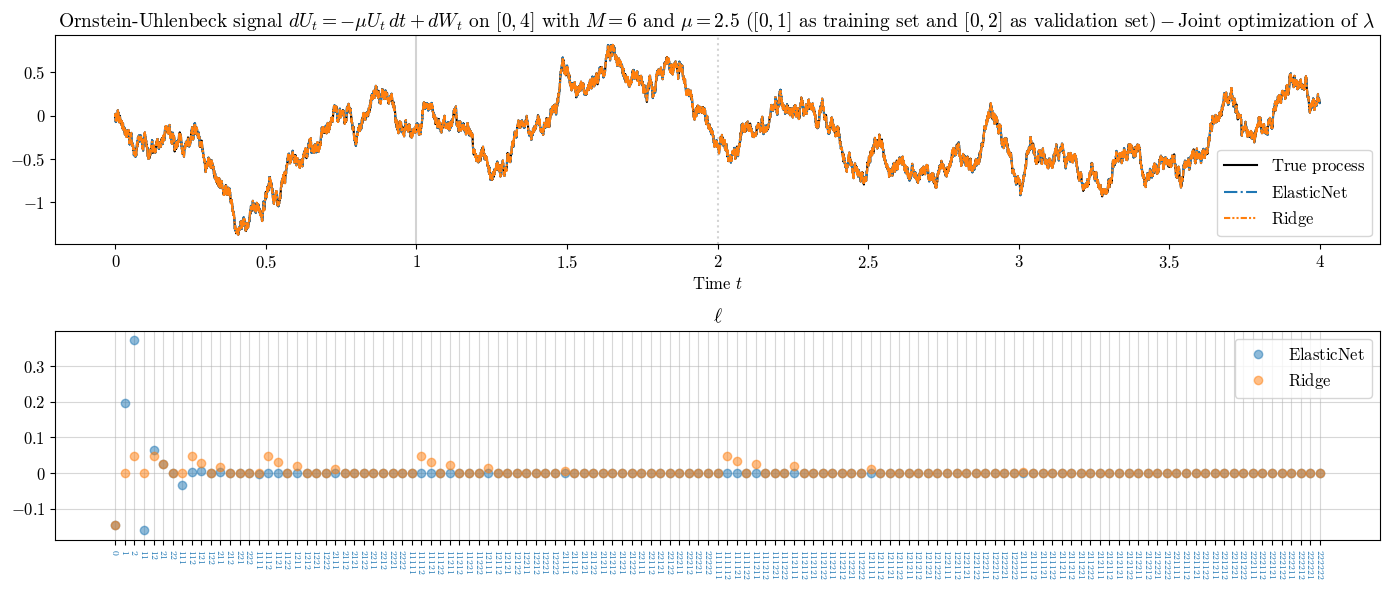

In [143]:
fig, ax = plt.subplots(2, 1, figsize=(14,6))
ax[0].axvline(1, color="lightgray", zorder=0)
ax[0].axvline(2, color="lightgray", linestyle=":", zorder=0)
ax[0].plot(t_main, Y, color="black", label=r"$\text{True process}$")
ax[0].plot(t_main, Y_EFM_ElasticNet, linestyle="-.", color="tab:blue", label=r"$\text{ElasticNet}$")
ax[0].plot(t_main, Y_EFM_Ridge, linestyle=(0, (3, 1, 1, 1, 1, 1)), color="tab:orange", label=r"$\text{Ridge}$") 
ax[0].set_xlabel(r"$\text{Time }t$", fontsize=12)
ax[0].tick_params(axis='both', labelsize=12) 
ax[0].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[0].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")

l_ElasticNet.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\text{ElasticNet}$")
l_Ridge.plot(ax=ax[1], size_x=7, alpha=0.5, label=r"$\text{Ridge}$")


for i in range(2) : 
    ax[i].legend(fontsize=12)

ax[0].set_title(r"$\text{Ornstein-Uhlenbeck signal }dU_t = -\mu U_t\, dt + dW_t \text{ on }[0,4] \text{ with }M=6 \text{ and } \mu=2.5\text{ (}[0,1] \text{ as training set and }[0,2] \text{ as validation set)} - \text{Joint optimization of }\lambda$ ", fontsize=14)
ax[1].set_title(r"$\ell$", fontsize=14)
plt.tight_layout()
plt.show()